 ### Instalação + Download + Verificação

In [ ]:
# Instalação biblioteca do kaggle caso necessário
%pip install kagglehub -q

import kagglehub
import os

# Download da versão mais recente
path = kagglehub.dataset_download("nih-chest-xrays/sample")
print("📂 Path do dataset:", path)

# Verificando estrutura de pastas
print("\n📁 Conteúdo da pasta raiz:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        n_files = len(os.listdir(item_path))
        print(f"  📂 {item}/  -> {n_files} arquivos")
    else:
        print(f"  📄 {item}")

Using Colab cache for faster access to the 'sample' dataset.
📂 Path do dataset: /kaggle/input/sample

📁 Conteúdo da pasta raiz:
  📄 sample_labels.csv
  📂 sample/  -> 3 arquivos


In [4]:
import glob

# Caminho corrigido - ajuste conforme o resultado do diagnóstico acima
images_path = os.path.join(path, "sample", "images")
all_images = glob.glob(os.path.join(images_path, "*.png"))

print(f"🖼️ Total de imagens encontradas: {len(all_images)}")
print(f"Exemplo de caminho: {all_images[0] if all_images else 'Nenhuma imagem encontrada'}")

csv_files = glob.glob(os.path.join(path, "*.csv"))
print(f"\n📊 Arquivos CSV encontrados: {csv_files}")

🖼️ Total de imagens encontradas: 5606
Exemplo de caminho: /kaggle/input/sample/sample/images/00006199_010.png

📊 Arquivos CSV encontrados: ['/kaggle/input/sample/sample_labels.csv']


In [5]:
# labels

import pandas as pd

df_labels = pd.read_csv(csv_files[0])
print("Shape do dataframe:", df_labels.shape)
print("\nColunas:", df_labels.columns.tolist())
df_labels.head()

Shape do dataframe: (5606, 11)

Colunas: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


### Redimensionar, Normalizar e Padronizar

In [6]:
import cv2
import numpy as np
from tqdm import tqdm

# Configurações
IMG_SIZE = 224  # tamanho padrão para CNNs (compatível com VGG16/ResNet)
SAMPLE_LIMIT = None  # defina um número (ex: 1000) para testar rápido, ou None para processar tudo

# Lista de imagens a processar
images_to_process = all_images[:SAMPLE_LIMIT] if SAMPLE_LIMIT else all_images
print(f"Processando {len(images_to_process)} imagens...")

# Listas para armazenar os resultados
processed_images = []
filenames = []

for img_path in tqdm(images_to_process):
    # Lê a imagem em escala de cinza (raio-X é naturalmente em tons de cinza)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue  # pula arquivos corrompidos/ilegíveis

    # Redimensiona para 224x224
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normaliza os pixels para o intervalo [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    processed_images.append(img_normalized)
    filenames.append(os.path.basename(img_path))

# Converte para array numpy
X = np.array(processed_images)
print(f"\n✅ Shape final do array de imagens: {X.shape}")
print(f"   (n_imagens, altura, largura) = {X.shape}")
print(f"Valores variam de {X.min()} a {X.max()} (deve ser 0.0 a 1.0)")

Processando 5606 imagens...


100%|██████████| 5606/5606 [02:03<00:00, 45.54it/s]



✅ Shape final do array de imagens: (5606, 224, 224)
   (n_imagens, altura, largura) = (5606, 224, 224)
Valores variam de 0.0 a 1.0 (deve ser 0.0 a 1.0)


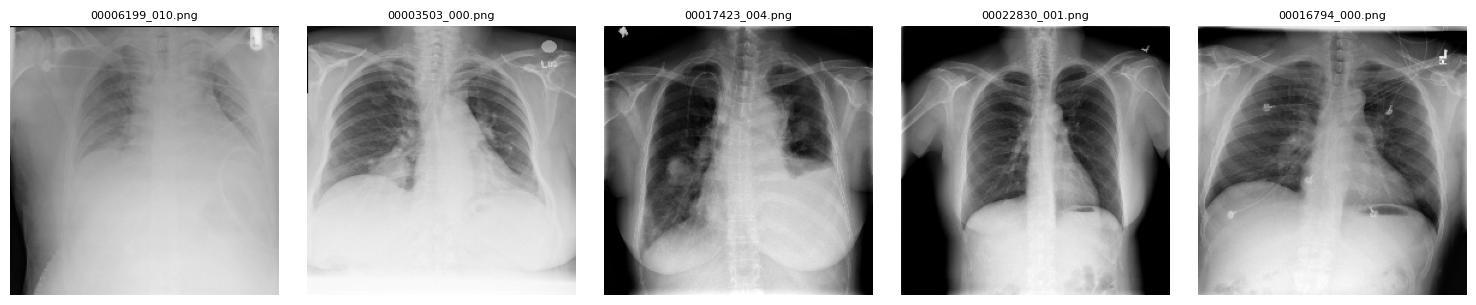

In [7]:
# Visualizando algumas imagens processadas
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(X[i], cmap='gray')
    axes[i].set_title(filenames[i], fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Criar a coluna de classe (binária)

In [8]:
# Criando a coluna alvo: 0 = Normal (No Finding), 1 = Doente (qualquer patologia)
df_labels['target'] = df_labels['Finding Labels'].apply(
    lambda x: 0 if x == 'No Finding' else 1
)

print(df_labels['target'].value_counts())
print(f"\nProporção: {df_labels['target'].value_counts(normalize=True)}")

target
0    3044
1    2562
Name: count, dtype: int64

Proporção: target
0    0.54299
1    0.45701
Name: proportion, dtype: float64


In [9]:
# Vamos garantir que X e os labels estejam na mesma ordem
# (df_labels tem 5606 linhas na ordem do CSV, mas all_images pode estar em ordem diferente do glob)

# Criando um dicionário: nome do arquivo -> índice na df_labels
df_labels_indexed = df_labels.set_index('Image Index')

# Reordenando y de acordo com a ordem de 'filenames' (que veio do processamento das imagens)
y = np.array([df_labels_indexed.loc[fname, 'target'] for fname in filenames])

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Distribuição de y: {np.bincount(y)}")

Shape de X: (5606, 224, 224)
Shape de y: (5606,)
Distribuição de y: [3044 2562]


### Split treino / validação / teste

In [10]:
from sklearn.model_selection import train_test_split

# Primeiro split: separa o teste (15%) do restante (85%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # mantém a proporção das classes em cada conjunto
)

# Segundo split: separa treino (70% do total) e validação (15% do total)
# 0.1765 de 85% ≈ 15% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]} imagens ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validação: {X_val.shape[0]} imagens ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]} imagens ({X_test.shape[0]/len(X)*100:.1f}%)")

Treino:    3923 imagens (70.0%)
Validação: 842 imagens (15.0%)
Teste:     841 imagens (15.0%)


In [11]:
# Verificando a proporção de classes
import pandas as pd

for nome, y_set in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    proporcao = np.bincount(y_set) / len(y_set)
    print(f"{nome}: Normal={proporcao[0]:.2%}, Doente={proporcao[1]:.2%}")

Treino: Normal=54.30%, Doente=45.70%
Validação: Normal=54.28%, Doente=45.72%
Teste: Normal=54.34%, Doente=45.66%


 ### Salvar os arrays para usar depois

In [12]:
# Salva os arrays em disco para não precisar reprocessar tudo de novo
np.savez('/content/dataset_split.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)

print("✅ Dataset salvo em /content/dataset_split.npz")
print(f"Tamanho do arquivo: {os.path.getsize('/content/dataset_split.npz') / 1e6:.1f} MB")

✅ Dataset salvo em /content/dataset_split.npz
Tamanho do arquivo: 1125.2 MB


# Parte 02

In [13]:
# Carregar o dataset

import numpy as np

# Caso esteja em uma nova sessão, recarregue o dataset salvo
data = np.load('/content/dataset_split.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

print(f"Treino:    {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste:     {X_test.shape}")

Treino:    (3923, 224, 224)
Validação: (842, 224, 224)
Teste:     (841, 224, 224)


In [14]:
X_train_cnn = X_train.reshape(-1, 224, 224, 1)
X_val_cnn = X_val.reshape(-1, 224, 224, 1)
X_test_cnn = X_test.reshape(-1, 224, 224, 1)

print(f"Treino:    {X_train_cnn.shape}")
print(f"Validação: {X_val_cnn.shape}")
print(f"Teste:     {X_test_cnn.shape}")

Treino:    (3923, 224, 224, 1)
Validação: (842, 224, 224, 1)
Teste:     (841, 224, 224, 1)


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Gerador com augmentation para o treino
train_datagen = ImageDataGenerator(
    rotation_range=5,        # rotação leve (raio-X tem orientação importante, não exagerar)
    width_shift_range=0.05,    # deslocamento horizontal
    height_shift_range=0.05,   # deslocamento vertical
    zoom_range=0.05,           # zoom leve
    horizontal_flip=False     # NÃO usar flip em raio-x de tórax (inverteria lado do coração)
)

# Validação não recebe augmentation, só os dados originais
val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train_cnn, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val_cnn, y_val, batch_size=32)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # observa o loss de validação
    patience=5,              # espera 3 épocas sem melhora antes de parar
    restore_best_weights=True  # ao parar, volta para os pesos do melhor ponto
)

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
history_cnn = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,  # reduzido de 15 -> 10 (early stopping pode parar antes mesmo disso)
    callbacks=[early_stop]
)

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 31s 186ms/step - accuracy: 0.5312 - loss: 0.7233 - val_accuracy: 0.5428 - val_loss: 0.6878
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.5384 - loss: 0.6920 - val_accuracy: 0.5404 - val_loss: 0.6884
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.5526 - loss: 0.6856 - val_accuracy: 0.5677 - val_loss: 0.6757
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.5868 - loss: 0.6718 - val_accuracy: 0.6330 - val_loss: 0.6485
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.6003 - loss: 0.6653 - val_accuracy: 0.6283 - val_loss: 0.6481
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - accuracy: 0.6067 - loss: 0.6618 - val_accuracy: 0.6437 - val_loss: 0.6487
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.6100 - loss: 0.6620 - val_accuracy: 0.6366 - val_loss: 0.6563
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.6115 - loss: 0

In [19]:
model_cnn.save('/content/model_cnn.h5')
print("✅ Modelo salvo!")

✅ Modelo salvo!


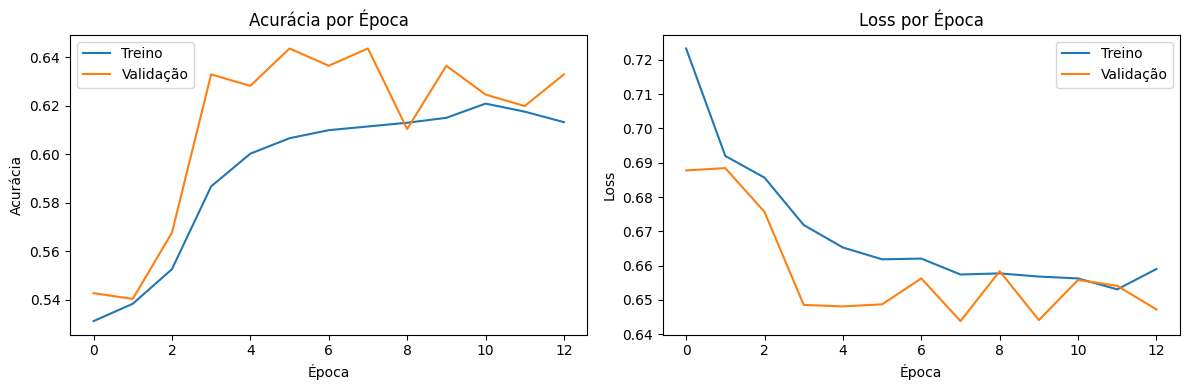

In [20]:
# Visualizar curvas de treino (acurácia e loss)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn.history['accuracy'], label='Treino')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'], label='Treino')
axes[1].plot(history_cnn.history['val_loss'], label='Validação')
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Avaliação com métricas

In [21]:
# Avaliação no conjunto de teste

# Previsões no conjunto de teste
y_pred_prob = model_cnn.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(f"Exemplo de probabilidades previstas: {y_pred_prob[:5].flatten()}")
print(f"Exemplo de classes previstas: {y_pred[:5]}")
print(f"Exemplo de classes reais:     {y_test[:5]}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Exemplo de probabilidades previstas: [0.46347904 0.33451825 0.48626477 0.34932345 0.37828767]
Exemplo de classes previstas: [0 0 0 0 0]
Exemplo de classes reais:     [0 0 1 0 1]


In [22]:
# Acurácia no teste

from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Acurácia no conjunto de teste: {test_accuracy:.2%}")

🎯 Acurácia no conjunto de teste: 63.97%


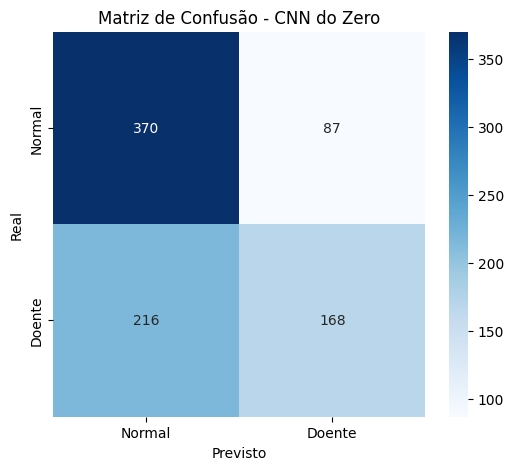


Verdadeiros Negativos (Normal correto): 370
Falsos Positivos (Normal previsto como Doente): 87
Falsos Negativos (Doente previsto como Normal): 216
Verdadeiros Positivos (Doente correto): 168


In [23]:
# Matriz de Confusão

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Doente'],
            yticklabels=['Normal', 'Doente'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - CNN do Zero')
plt.show()

print(f"\nVerdadeiros Negativos (Normal correto): {cm[0][0]}")
print(f"Falsos Positivos (Normal previsto como Doente): {cm[0][1]}")
print(f"Falsos Negativos (Doente previsto como Normal): {cm[1][0]}")
print(f"Verdadeiros Positivos (Doente correto): {cm[1][1]}")

In [24]:
# Precisão, Recall e F1-Score

from sklearn.metrics import classification_report

print("📋 Relatório de Classificação - CNN do Zero\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Doente']))

📋 Relatório de Classificação - CNN do Zero

              precision    recall  f1-score   support

      Normal       0.63      0.81      0.71       457
      Doente       0.66      0.44      0.53       384

    accuracy                           0.64       841
   macro avg       0.65      0.62      0.62       841
weighted avg       0.64      0.64      0.63       841



In [25]:
# Resumo consolidado das métricas

from sklearn.metrics import precision_score, recall_score, f1_score

resultados_cnn_zero = {
    'Modelo': 'CNN do Zero',
    'Acurácia': accuracy_score(y_test, y_pred),
    'Precisão': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}

for k, v in resultados_cnn_zero.items():
    if k != 'Modelo':
        print(f"{k}: {v:.2%}")
    else:
        print(f"{k}: {v}")

Modelo: CNN do Zero
Acurácia: 63.97%
Precisão: 65.88%
Recall: 43.75%
F1-Score: 52.58%


Transfer Learning

In [26]:
# Preparar imagens em RGB

import gc
from tensorflow.keras.applications.resnet50 import preprocess_input

def preparar_resnet(X_gray_0to1):
    X_rgb = np.repeat(X_gray_0to1, 3, axis=-1) * 255.0
    return preprocess_input(X_rgb)

X_train_resnet = preparar_resnet(X_train_cnn)
del X_train_cnn
gc.collect()

X_val_resnet = preparar_resnet(X_val_cnn)
del X_val_cnn
gc.collect()

X_test_resnet = preparar_resnet(X_test_cnn)
del X_test_cnn
gc.collect()

print(f"Treino:    {X_train_resnet.shape}")
print(f"Validação: {X_val_resnet.shape}")
print(f"Teste:     {X_test_resnet.shape}")

Treino:    (3923, 224, 224, 3)
Validação: (842, 224, 224, 3)
Teste:     (841, 224, 224, 3)


In [27]:
# Carregar ResNet50 pré-treinado e congelar camadas

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Carrega o ResNet50 sem a camada de classificação final (include_top=False)
# weights='imagenet' usa os pesos já treinados em milhões de imagens
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congela as camadas convolucionais (não serão retreinadas)
base_model.trainable = False

print(f"Número de camadas no modelo base: {len(base_model.layers)}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Número de camadas no modelo base: 175


In [28]:
# Adicionar camadas de classificação no final

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # reduz dimensão sem "achatar" tudo como o Flatten faria
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # saída binária: Normal (0) ou Doente (1)
])

model_resnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [29]:
# Compilar o modelo

model_resnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
# Data Augmentation + Early Stopping (reaproveitando a lógica anterior)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

train_datagen_resnet = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=False
)

val_datagen_resnet = ImageDataGenerator()

train_generator_resnet = train_datagen_resnet.flow(X_train_resnet, y_train, batch_size=16)
val_generator_resnet = val_datagen_resnet.flow(X_val_resnet, y_val, batch_size=16)

early_stop_resnet = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [31]:
# Treinar o modelo
history_resnet = model_resnet.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=15,
    callbacks=[early_stop_resnet]
)

Epoch 1/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 75s 256ms/step - accuracy: 0.6001 - loss: 0.7003 - val_accuracy: 0.6568 - val_loss: 0.6344
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 51s 209ms/step - accuracy: 0.6255 - loss: 0.6480 - val_accuracy: 0.6093 - val_loss: 0.6905
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 51s 209ms/step - accuracy: 0.6383 - loss: 0.6433 - val_accuracy: 0.6710 - val_loss: 0.6343
Epoch 4/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 51s 208ms/step - accuracy: 0.6406 - loss: 0.6397 - val_accuracy: 0.6639 - val_loss: 0.6293
Epoch 5/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 52s 211ms/step - accuracy: 0.6357 - loss: 0.6334 - val_accuracy: 0.6615 - val_loss: 0.6238
Epoch 6/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 51s 209ms/step - accuracy: 0.6549 - loss: 0.6268 - val_accuracy: 0.6627 - val_loss: 0.6353
Epoch 7/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 52s 211ms/step - accuracy: 0.6380 - loss: 0.6367 - val_accuracy: 0.6615 - val_loss: 0.6256
Epoch 8/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 52s 210ms/step - accuracy: 0.6574 - loss: 0

In [32]:
#  Salvar o modelo
model_resnet.save('/content/model_resnet.h5')
print("✅ Modelo ResNet50 salvo!")

✅ Modelo ResNet50 salvo!


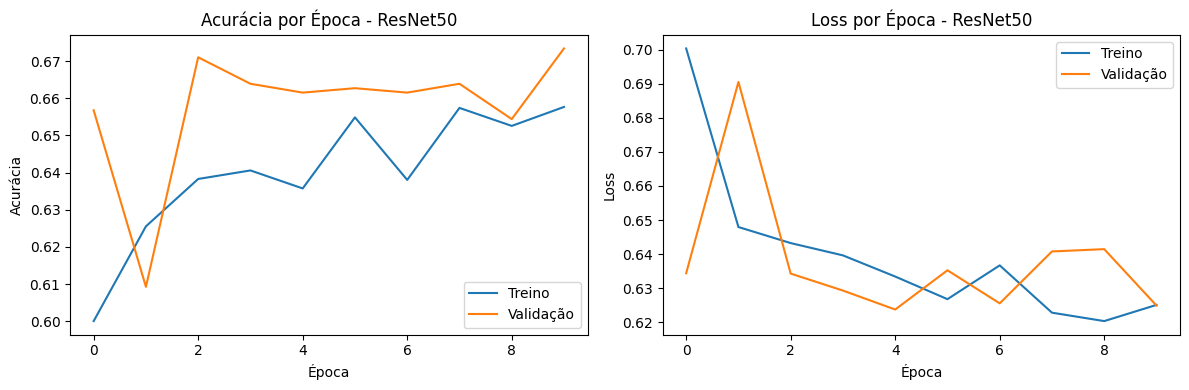

In [33]:
# Gráfico de Acurácia e Loss — ResNet50
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_resnet.history['accuracy'], label='Treino')
axes[0].plot(history_resnet.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia por Época - ResNet50')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

axes[1].plot(history_resnet.history['loss'], label='Treino')
axes[1].plot(history_resnet.history['val_loss'], label='Validação')
axes[1].set_title('Loss por Época - ResNet50')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
# Importações

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# Probabilidades previstas

y_pred_prob = model_resnet.predict(
    X_test_resnet,
    verbose=1
)

# Converter para classes 0 ou 1

y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Total de amostras:", len(y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 328ms/step
Total de amostras: 841


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("RESNET50 - RESULTADOS")
print("="*50)

print(f"Acurácia : {accuracy:.4f}")
print(f"Precisão : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

RESNET50 - RESULTADOS
Acurácia : 0.6849
Precisão : 0.6964
Recall    : 0.5495
F1-Score  : 0.6143


In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Doente"]
    )
)

              precision    recall  f1-score   support

      Normal       0.68      0.80      0.73       457
      Doente       0.70      0.55      0.61       384

    accuracy                           0.68       841
   macro avg       0.69      0.67      0.67       841
weighted avg       0.69      0.68      0.68       841



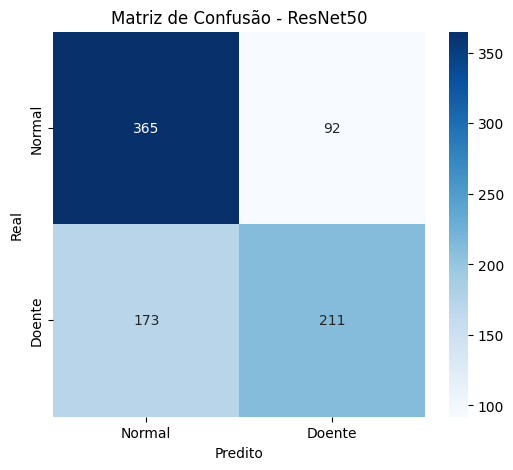

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Doente"],
    yticklabels=["Normal", "Doente"]
)

plt.title("Matriz de Confusão - ResNet50")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

In [44]:
import pandas as pd

metricas_resnet = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Valor": [accuracy, precision, recall, f1]
})

metricas_resnet

,Métrica,Valor
0,Accuracy,0.684899
1,Precision,0.696370
2,Recall,0.549479
3,F1-Score,0.614265


In [40]:
# ─── Instalação (caso necessário) ───────────────────────────────────────────
!pip install ipywidgets -q

In [41]:
# ─── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import cv2
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# ─── Carregar modelos salvos ─────────────────────────────────────────────────
# Certifique-se de que os arquivos .h5 foram salvos nas células anteriores
model_cnn    = load_model('/content/model_cnn.h5')
model_resnet = load_model('/content/model_resnet.h5')

print('✅ Modelos carregados com sucesso!')

✅ Modelos carregados com sucesso!


In [42]:
# ─── Funções de pré-processamento ───────────────────────────────────────────

IMG_SIZE = 224

def preprocessar_para_cnn(img_bytes):
    """Converte bytes de imagem → array pronto para a CNN do zero."""
    arr = np.frombuffer(img_bytes, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    return img.reshape(1, IMG_SIZE, IMG_SIZE, 1)   # (1, 224, 224, 1)

def preprocessar_para_resnet(img_bytes):
    """Converte bytes de imagem → array pronto para o ResNet50."""
    arr = np.frombuffer(img_bytes, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm = img.astype(np.float32) / 255.0
    img_rgb  = np.repeat(img_norm.reshape(IMG_SIZE, IMG_SIZE, 1), 3, axis=-1) * 255.0
    return preprocess_input(img_rgb.reshape(1, IMG_SIZE, IMG_SIZE, 3))

def classificar(img_bytes, modelo_nome):
    """Roda a predição e retorna (label, probabilidade)."""
    if modelo_nome == 'CNN do Zero':
        X = preprocessar_para_cnn(img_bytes)
        prob = float(model_cnn.predict(X, verbose=0)[0][0])
    else:
        X = preprocessar_para_resnet(img_bytes)
        prob = float(model_resnet.predict(X, verbose=0)[0][0])

    label = 'Doente' if prob >= 0.5 else 'Normal'
    return label, prob

In [43]:
# ─── Interface interativa ────────────────────────────────────────────────────

# --- Widgets ---
titulo = widgets.HTML(
    value="<h2 style='color:#1a73e8; font-family:sans-serif;'>"
          "🫁 Assistente Cardiológico Virtual — CardioIA</h2>"
          "<p style='font-family:sans-serif; color:#555;'>"
          "Faça upload de um raio-X de tórax (.png ou .jpg) e escolha o modelo."
          "</p>"
)

upload_btn = widgets.FileUpload(
    accept='.png,.jpg,.jpeg',
    multiple=False,
    description='📂 Carregar imagem',
    layout=widgets.Layout(width='220px')
)

modelo_selector = widgets.ToggleButtons(
    options=['CNN do Zero', 'ResNet50 (Transfer Learning)'],
    description='Modelo:',
    button_style='info',
    style={'description_width': '60px'}
)

classificar_btn = widgets.Button(
    description='🔍 Classificar',
    button_style='success',
    layout=widgets.Layout(width='160px', height='40px')
)

output_area = widgets.Output()

# --- Callback do botão ---
def on_classificar(b):
    with output_area:
        clear_output(wait=True)

        if not upload_btn.value:
            print('⚠️  Por favor, carregue uma imagem primeiro.')
            return

        # Lê os bytes do arquivo carregado
        uploaded_file = list(upload_btn.value.values())[0]
        img_bytes = uploaded_file['content']

        modelo_nome = modelo_selector.value

        # Predição
        try:
            label, prob = classificar(img_bytes, modelo_nome)
        except Exception as e:
            print(f'❌ Erro ao classificar: {e}')
            return

        # Exibição dos resultados
        cor_resultado = '#d32f2f' if label == 'Doente' else '#388e3c'
        emoji = '🔴' if label == 'Doente' else '🟢'

        # Decodifica a imagem original para exibir
        arr = np.frombuffer(img_bytes, dtype=np.uint8)
        img_display = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                                  gridspec_kw={'width_ratios': [1, 1.2]})
        fig.patch.set_facecolor('#f8f9fa')

        # --- Painel esquerdo: imagem ---
        axes[0].imshow(img_display, cmap='gray')
        axes[0].set_title('Raio-X carregado', fontsize=13, fontweight='bold')
        axes[0].axis('off')

        # --- Painel direito: resultado ---
        axes[1].set_xlim(0, 1)
        axes[1].set_ylim(0, 1)
        axes[1].axis('off')
        axes[1].set_facecolor('#f8f9fa')

        # Resultado principal
        axes[1].text(0.5, 0.82, f'{emoji}  {label}',
                     ha='center', va='center', fontsize=28, fontweight='bold',
                     color=cor_resultado)

        # Modelo usado
        axes[1].text(0.5, 0.68, f'Modelo: {modelo_nome}',
                     ha='center', va='center', fontsize=11, color='#555')

        # Barra de probabilidade
        prob_doente = prob
        prob_normal = 1 - prob

        bar_y = 0.50
        axes[1].barh(bar_y, prob_doente, height=0.08,
                     color='#ef9a9a', left=0.05, label='Doente')
        axes[1].barh(bar_y, prob_normal, height=0.08,
                     color='#a5d6a7', left=0.05 + prob_doente, label='Normal')
        axes[1].text(0.5, 0.41,
                     f'Prob. Doente: {prob_doente:.1%}   |   Prob. Normal: {prob_normal:.1%}',
                     ha='center', va='center', fontsize=10, color='#333')

        # Legenda da barra
        patch_d = mpatches.Patch(color='#ef9a9a', label='Doente')
        patch_n = mpatches.Patch(color='#a5d6a7', label='Normal')
        axes[1].legend(handles=[patch_d, patch_n],
                        loc='lower center', ncol=2, fontsize=10,
                        bbox_to_anchor=(0.5, 0.02))

        # Aviso ético
        axes[1].text(0.5, 0.22,
                     '⚠️  Este resultado é gerado por IA e possui fins\n'
                     'exclusivamente educacionais. Não substitui\n'
                     'avaliação médica profissional.',
                     ha='center', va='center', fontsize=9,
                     color='#888', style='italic')

        plt.tight_layout()
        plt.show()

classificar_btn.on_click(on_classificar)

# --- Layout final ---
controles = widgets.VBox([
    titulo,
    widgets.HBox([upload_btn, modelo_selector]),
    classificar_btn,
    output_area
])

display(controles)